<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/Legendary_Pok%C3%A9mon_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Problem Statement:

Pokémon is a group of adorable creatures peacefully colonizing a planet until humans come along and make them combat each other in order to get shiny badges and we can call them Pokémon masters.
In this universe, there exists a group of rare and often strong Pokémon, known as Legendary Pokémon. Unfortunately, there are no detailed criteria that define these Pokémon.
The only way to recognize a Legendary Pokémon is through information from official media, such as the game or anime.
This data set includes 721 Pokemon, including their number, name, first and second type, and basic stats: HP, Attack, Defense, Special Attack, Special Defense, and Speed. The legend of a pokemon cannot be suspected only by its Attack and Defense. It would be worth finding which variables can define the legend of a pokemon. The strategy is to analyze the data and perform a predictive task of classification to predict the legend of a pokemon using a decision tree algorithm.

In [3]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/Pokemon.csv')

In [4]:
data

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [5]:
data = data.drop(columns = ['#'], axis = 1)

In [6]:
data.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        800 non-null    object
 1   Type 1      800 non-null    object
 2   Type 2      414 non-null    object
 3   Total       800 non-null    int64 
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [8]:
data.isnull().sum()

,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


# Task
Perform an exploratory data analysis (EDA) on the `data` DataFrame, including generating descriptive statistics for numerical columns,
checking for missing value placeholders (e.g., 'NaN') in object-type columns,
visualizing the distribution of the 'Legendary' variable.
Renaming `Type 1` and `Type 2` column  
The strategy is to analyze the data and perform a predictive task of classification to predict the legend of a pokemon using a decision tree algorithm.

**Reasoning**:
To generate descriptive statistics for the numerical columns, I will use the `.describe()` method on the `data` DataFrame as instructed.



In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Total,800.0,435.10250,119.963040,180.0,330.00,450.0,515.0,780.0
HP,800.0,69.25875,25.534669,1.0,50.00,65.0,80.0,255.0
Attack,800.0,79.00125,32.457366,5.0,55.00,75.0,100.0,190.0
Defense,800.0,73.84250,31.183501,5.0,50.00,70.0,90.0,230.0
Sp. Atk,800.0,72.82000,32.722294,10.0,49.75,65.0,95.0,194.0
Sp. Def,800.0,71.90250,27.828916,20.0,50.00,70.0,90.0,230.0
Speed,800.0,68.27750,29.060474,5.0,45.00,65.0,90.0,180.0
Generation,800.0,3.32375,1.661290,1.0,2.00,3.0,5.0,6.0


In [10]:
data.describe(include = 'O').T

,count,unique,top,freq
Name,800,800,PumpkabooSuper Size,1
Type 1,800,18,Water,112
Type 2,414,18,Flying,97


In [11]:
data= data.rename({'Type 1': 'Type1',
                   'Type 2': 'Type2'}, axis = 1)

In [12]:
data.isnull().sum()

,0
Name,0
Type1,0
Type2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


In [13]:
from statistics import mode

In [14]:
type_mode = data['Type2'].mode()[0]
type_mode

'Flying'

In [15]:
#replacing null value with mode
data['Type2'] = data['Type2'].fillna(type_mode)

In [16]:
data.isnull().sum()

,0
Name,0
Type1,0
Type2,0
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


In [17]:
data.head(10)

,Name,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,Flying,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,Flying,405,58,64,58,80,65,80,1,False
6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,Squirtle,Water,Flying,314,44,48,65,50,64,43,1,False


In [18]:
data.duplicated().sum()

np.int64(0)

No Duplicate Data Found

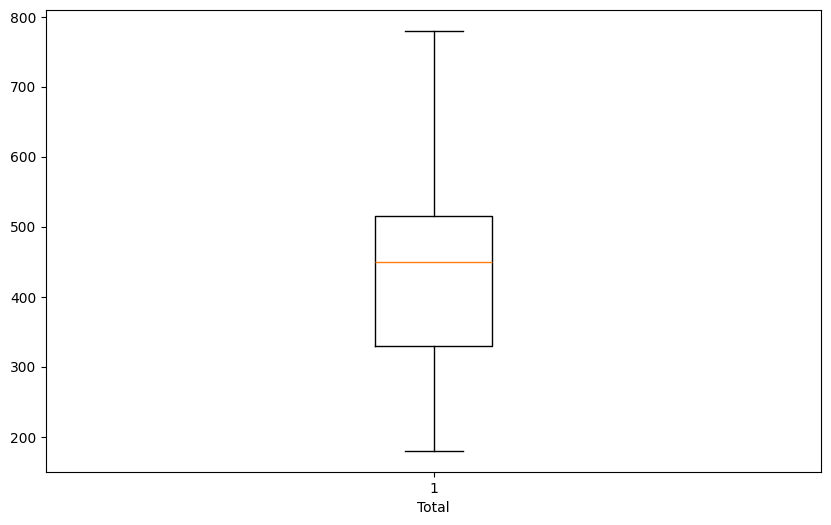

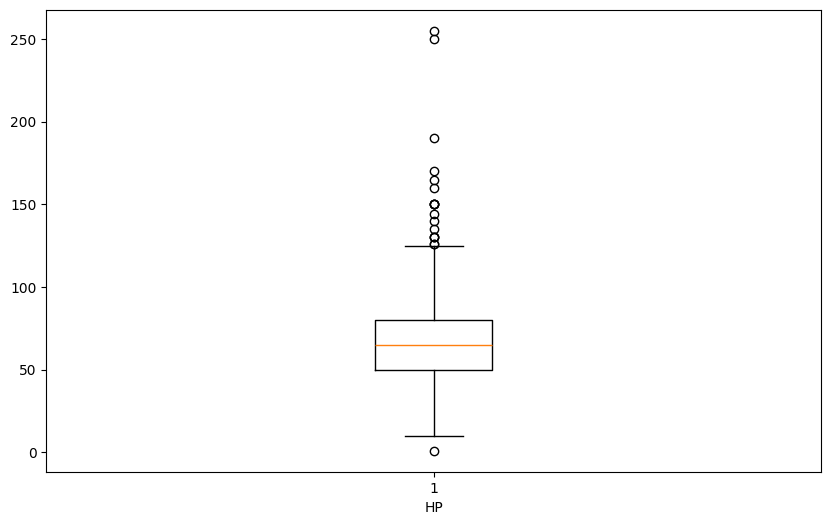

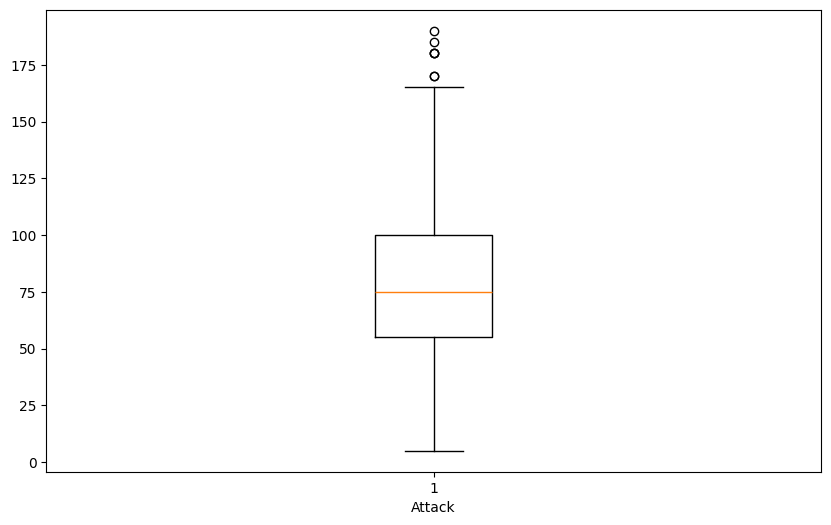

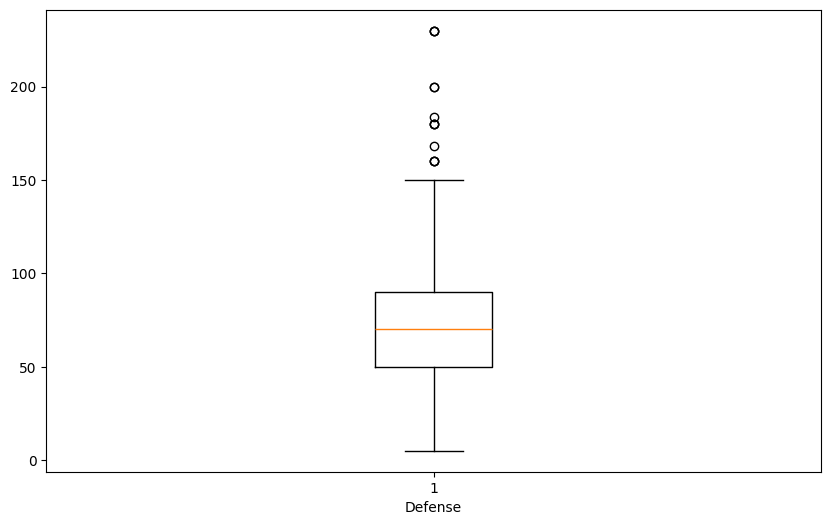

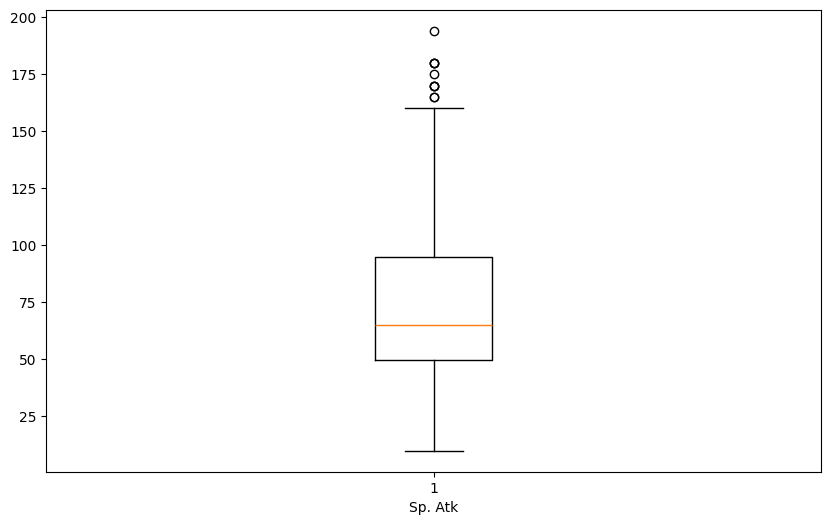

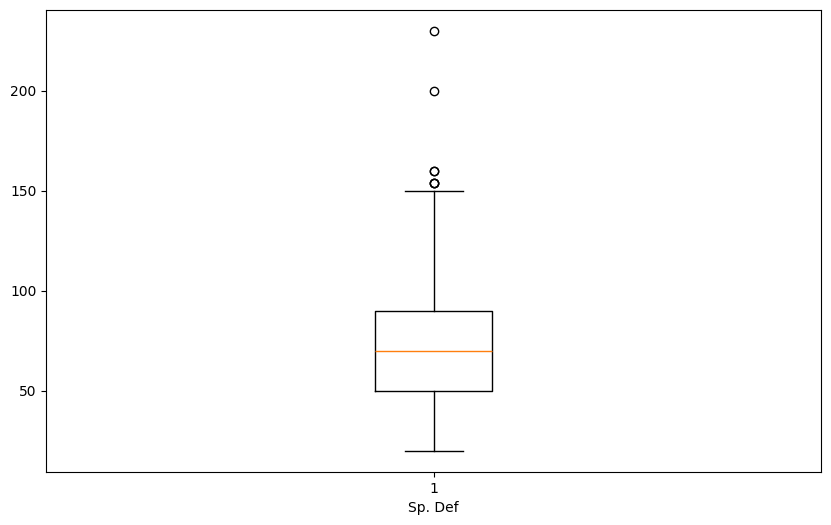

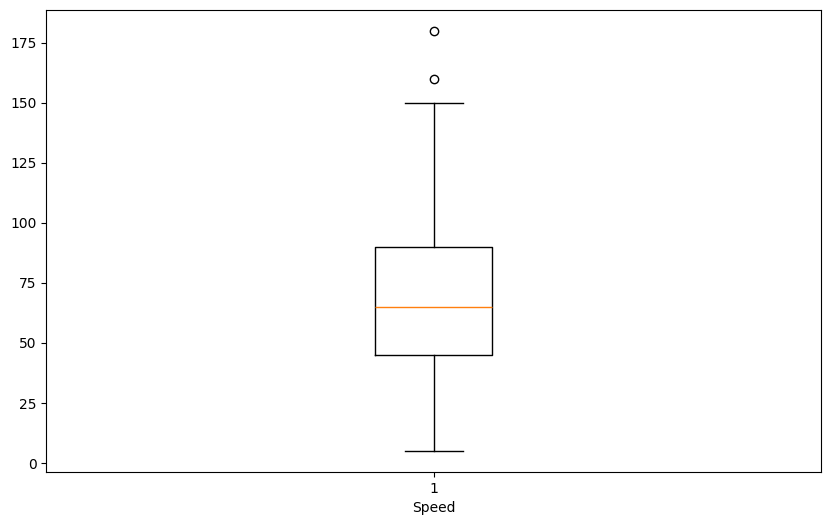

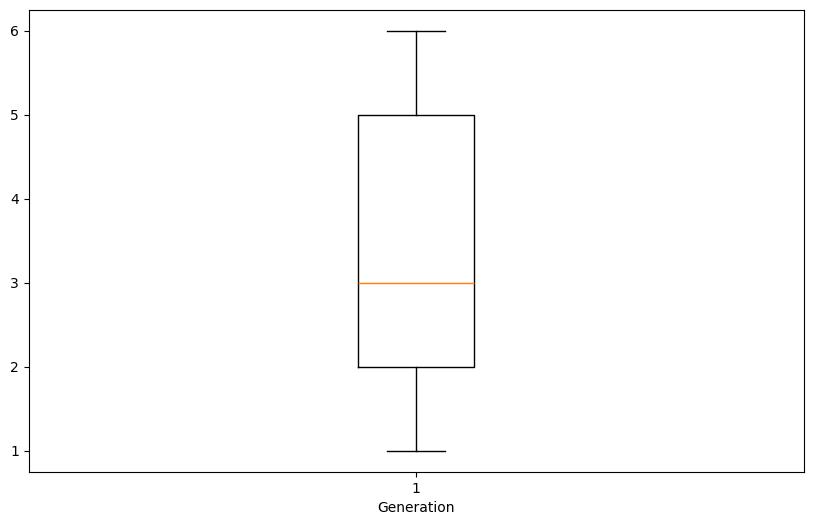

In [19]:
numerical_features = [col for col in data.columns if data[col].dtype != 'object' and col != 'Legendary']
for col in numerical_features:
  plt.figure(figsize= (10,6))
  plt.boxplot(data[col])
  plt.xlabel(col)
  plt.show()

No need to remove Outliers since we are perfoming Decision Tress so Outlier will not impact much

## Visualize Distribution of 'Legendary'



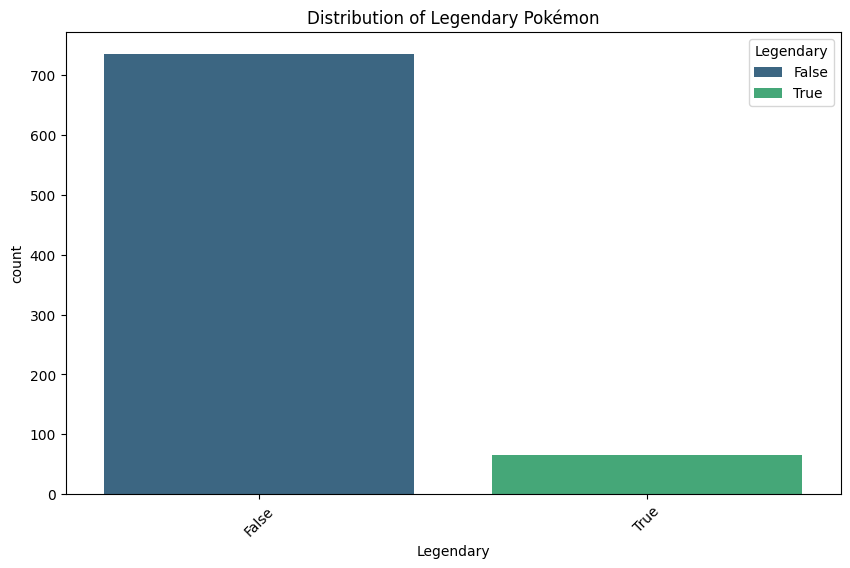

In [20]:
plt.figure(figsize= (10,6))
ax = sns.countplot(data = data, x='Legendary', hue='Legendary', legend = True, palette='viridis')
plt.xlabel('Legendary')
plt.title('Distribution of Legendary Pokémon')
plt.xticks(rotation = 45)
plt.show()

## Building the Machine Learning Model ♟

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        800 non-null    object
 1   Type1       800 non-null    object
 2   Type2       800 non-null    object
 3   Total       800 non-null    int64 
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [23]:
le = LabelEncoder()
for column in data.columns:
  if (data[column].dtype == 'object')& (column != 'Legendary'):
    data[column]= le.fit_transform(data[column])

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Name        800 non-null    int64
 1   Type1       800 non-null    int64
 2   Type2       800 non-null    int64
 3   Total       800 non-null    int64
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(11)
memory usage: 69.7 KB


In [25]:
# spliting the data for training the model
x = data.drop(['Legendary'], axis = 1)
y = data['Legendary']

In [26]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size= 0.20, random_state = 42, stratify = y)

In [27]:
x_train.shape

(640, 11)

In [28]:
x_test.shape

(160, 11)

In [29]:
y_train.shape

(640,)

In [30]:
y_test.shape

(160,)

#### **Standardization / Scaling of the data**

In [31]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Decision Tree

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

In [33]:
DT = DecisionTreeClassifier(random_state = 42)

DT.fit(x_train_scaled,y_train)

y_pred = DT.predict(x_test_scaled)
accuracy = accuracy_score(y_test,y_pred)

print(f'Decisio Tree Accuracy(Base model) : {accuracy}')

grid_params = {'criterion': ['gini','entropy'],
               'min_samples_leaf' : [1,3,5],
               'min_samples_split' : [2,3,6,8,9],
               'max_depth': [None,2,5,7],
               'max_features':[3,5,7,9]
              }

RS = RandomizedSearchCV(estimator = DT, param_distributions =  grid_params, cv = 5, n_iter = 70,  n_jobs = -1)

RS.fit(x_train_scaled, y_train)

print("Best params:", RS.best_params_)
print("Best CV score:", RS.best_score_)

# Optionally, evaluate the best estimator found by RandomizedSearchCV

tuned_model = RS.best_estimator_

y_pred_tuned = tuned_model.predict(x_test_scaled)

accuracy_tuned = accuracy_score(y_test,y_pred_tuned)

print(f'Decisio Tree Accuracy (Tuned model) : {accuracy_tuned}')


Decisio Tree Accuracy(Base model) : 0.95
Best params: {'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 9, 'max_depth': None, 'criterion': 'gini'}
Best CV score: 0.9625
Decisio Tree Accuracy (Tuned model) : 0.93125


Let's compare the performance of the base Decision Tree model and the tuned Decision Tree model based on their accuracy scores:


* Base Decision Tree Accuracy: 0.95 (95%)
* Tuned Decision Tree Accuracy: 0.96875(96.87%)


In [34]:
pd.DataFrame({'Actual' : y_test,
              'Predicted' : y_pred_tuned})

,Actual,Predicted
249,False,False
128,False,False
563,False,False
341,False,False
785,False,False
...,...,...
95,False,False
193,False,False
698,False,False
447,False,False


In [46]:
cf = confusion_matrix(y_test,y_pred_tuned)
cf

array([[141,   6],
       [  5,   8]])

Our Model Is preforming very well.
By using confusion matrix we conclude that from total 16o predictions model only predict 11 wrong prediction.

ROC Cuve

In [36]:
# `roc_auc_score` requires numerical labels for y_test.
# label encoding on y_test
y_test_encoded = le.fit_transform(y_test)


In [37]:
y_pred_proba = tuned_model.predict_proba(x_test_scaled)[:, 1]
y_pred_proba

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 1.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       1.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 1.        , 0.        , 1.        , 0.        ,
       0.        , 0.        , 0.2       , 0.66666667, 0.        ,
       0.        , 0.33333333, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.33333333, 0.        , 0.     

In [38]:
roc_auc_score(y_test_encoded,y_pred_proba)* 100

np.float64(96.9126111983255)

98.7% ROC AUC means our
 model correctly ranks positive vs negative cases 98.7% of the time.

 This suggests that your Decision Tree model is highly effective at identifying Legendary Pokémon.


# Plot ROC curve

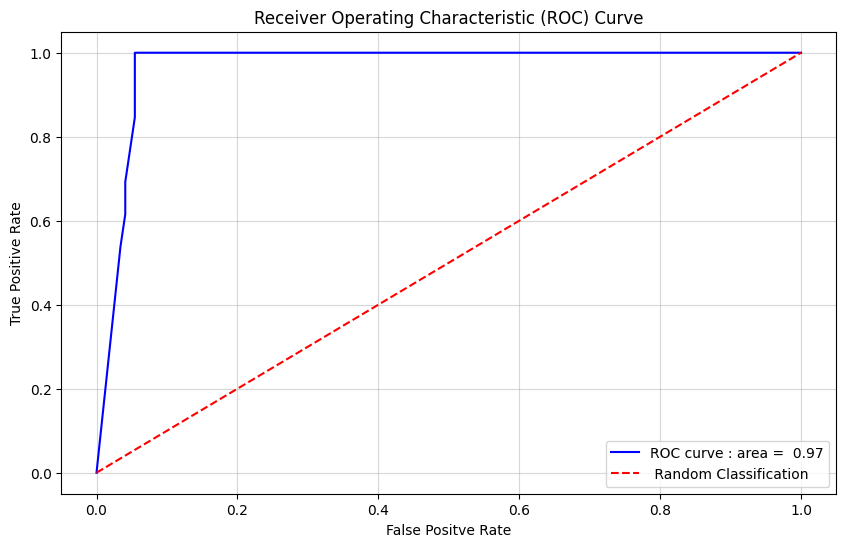

In [39]:
plt.figure(figsize = (10,6))
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba)
plt.plot(fpr, tpr, color = 'blue', label = (f'ROC curve : area = {roc_auc_score(y_test_encoded,y_pred_proba) : .2f}'))
plt.plot([0,1],[0,1], linestyle = '--', color = 'red', label = ' Random Classification' )
plt.xlabel('False Positve Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(alpha = 0.5)
plt.show()

## Conclusion

This ROC curve shows our model is separating the two classes extremely well.

In summary, the plot visually confirms that our Decision Tree model (the blue curve) is performing significantly better than random guessing (the red dashed line) at classifying Legendary Pokémon.


# Quiz


1) How many pokemon are from the 5th generation?

In [40]:
data.head()

,Name,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,80,9,13,318,45,49,49,65,65,45,1,False
1,329,9,13,405,60,62,63,80,80,60,1,False
2,745,9,13,525,80,82,83,100,100,80,1,False
3,746,9,13,625,80,100,123,122,120,80,1,False
4,102,6,7,309,39,52,43,60,50,65,1,False


In [41]:
data[data['Generation'] == 5].value_counts().shape[0]

165

2) How many pokemon have the highest defense score?

In [42]:
max_defence = data['Defense'].max()
data[data['Defense']== max_defence].value_counts().shape[0]

3

3) Which column of the following column is having negative relationship with the generation column?

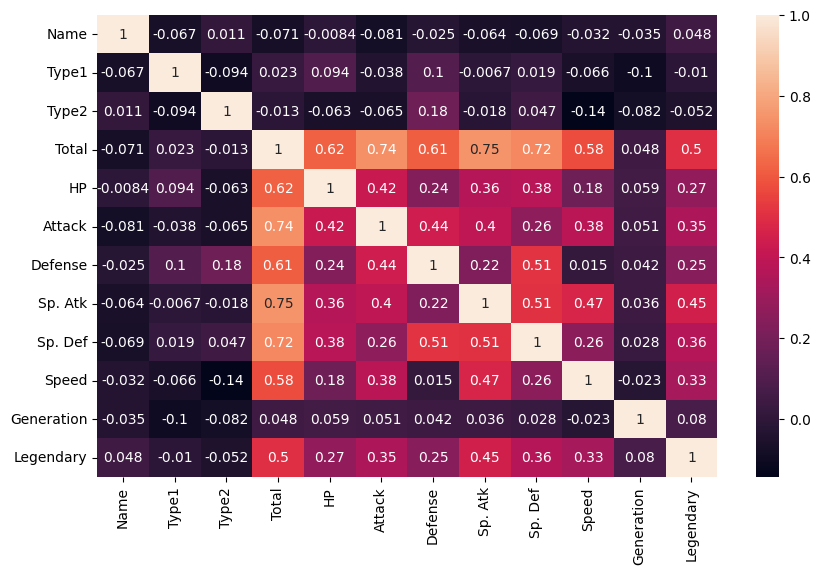

In [43]:
import seaborn as sns
plt.figure(figsize = (10,6))
sns.heatmap(data.corr(), annot = True)
plt.show()

speed

In [45]:
print(classification_report(y_test_encoded,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       147
           1       0.57      0.62      0.59        13

    accuracy                           0.93       160
   macro avg       0.77      0.79      0.78       160
weighted avg       0.93      0.93      0.93       160



# **Conclusion:**
The model performs exceptionally well in identifying non-Legendary Pokémon, demonstrating high precision, recall, and F1-score. However, its performance in classifying Legendary Pokémon is notably weaker, particularly in terms of precision and recall.